In [4]:
from semipy import semiformal, semi, configure
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
from pathlib import Path

CACHE_DIR = '/Users/r4yen/Desktop/Research/semi-formal/repo/semipy-package/.semiformal-datetime-usecase'
# Stable portal anchor: basename becomes session id (see semipy.session_anchor). Use the examples dir to match a shared portal for this repo layout.
_SESSION_SOURCE = str((Path(CACHE_DIR).resolve().parent / "examples").resolve())
configure(cache_dir=CACHE_DIR, session_source=_SESSION_SOURCE)

@semiformal
def infer_datetime_formatter(date_str: str) -> str:
    input_pattern = ... #> infer the input date regex/strptime pattern from the observed string format in this session.
    output_pattern = "%b %Y"

    return datetime.strptime(str(date_str), input_pattern).strftime(output_pattern)


data = pd.DataFrame(
    {
        "signup_date": [
            "03/14/2025",
            "03/20/2025",
            "04/05/2025",
            "04/18/2025",
            "05-01-2025",
            "05-12-2025 11:30",
            "08-18-2025 09:30:00",
            "06-18-2025 9:11",
            "June 21 2025",
            "July 09 2026",
            "Aug 2026",
            "09:30:00"
        ]
    }
)

data["formatted_signup_date"] = data["signup_date"].apply(infer_datetime_formatter)

Output()

%m/%d/%Y
%m/%d/%Y


  3698199520.py:25 (infer_datetime_formatter) Runtime check passed for current inputs.

%m/%d/%Y
%m/%d/%Y


  3698199520.py:25 (infer_datetime_formatter) Runtime check passed for current inputs.

...

%B %d %Y
%B %d %Y


  3698199520.py:25 (infer_datetime_formatter) Runtime check passed for current inputs.

%B %d %Y



  3698199520.py:25 (infer_datetime_formatter) Runtime check passed for current inputs.

  3698199520.py:25 (infer_datetime_formatter) Runtime check passed for current inputs.

Reused slots re-run execution/type checks when current inputs differ from the commit fingerprint (set at generation). Verify failures log when `verbose` is on. With default `verbose`, model output uses peek streaming; completed reasoning parts also print as **Reasoning** panels. Use `print_portal_resolution_summary` below to inspect portal state. PDF backend: set env `SEMIPY_DOCUMENT_PDF_BACKEND` / `SEMIPY_DOCUMENT_LAYOUT_HEAVY` if needed.

In [5]:
for date in data["formatted_signup_date"]:
    print(date)

Mar 2025
Mar 2025
Apr 2025
Apr 2025
May 2025



Jun 2025
Jul 2026




In [3]:
new_data = pd.DataFrame(
    {
        "signup_date": [
            "06/18/2025 11:30",
            "09-21-2025",
            "09-21-2025 11:30",
            "01-01-2025",
            "12/01/2025 11:30:00",
            "01/01/2025 11:30:00",
            "12/01/2025 11:30",
            "January 1 2025",
            "Sep 2025",
            "01.21.2025 11:30:00",
            "02.21.2025 11:30:00:00",
            "02.21.2025 11:30:00:00:00",
            
        ]
    }
)

new_data["formatted_signup_date"] = new_data["signup_date"].apply(infer_datetime_formatter)
new_data["formatted_signup_date"].value_counts()

  424732306.py:25 (infer_datetime_formatter) Runtime check passed for current inputs.

  424732306.py:25 (infer_datetime_formatter) Runtime check passed for current inputs.

  424732306.py:25 (infer_datetime_formatter) Runtime check passed for current inputs.

  424732306.py:25 (infer_datetime_formatter) Runtime check passed for current inputs.

  424732306.py:25 (infer_datetime_formatter) Runtime check passed for current inputs.

...

  424732306.py:25 (infer_datetime_formatter) Runtime check passed for current inputs.

  424732306.py:25 (infer_datetime_formatter) Runtime check passed for current inputs.

  424732306.py:25 (infer_datetime_formatter) Runtime check passed for current inputs.

  424732306.py:25 (infer_datetime_formatter) Runtime check passed for current inputs.

formatted_signup_date
            8
Sep 2025    2
Jan 2025    2
Name: count, dtype: int64

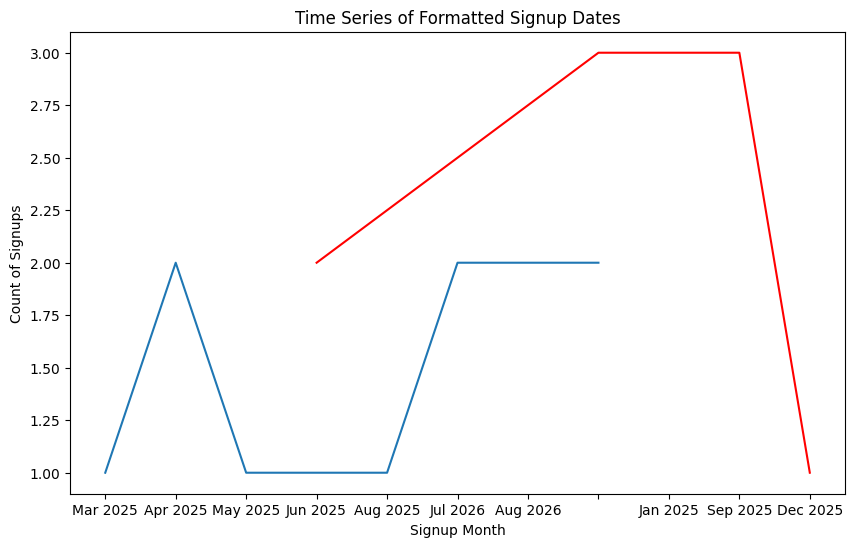

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))
data_monthly = (
    data.groupby("formatted_signup_date")
    .size()
    .reset_index(name="count")
)
# data_monthly
new_data_monthly = (
    new_data.groupby("formatted_signup_date")
    .size()
    .reset_index(name="count")
)

sns.lineplot(
    x=semi(f"sort the following dates: {data_monthly['formatted_signup_date'].tolist()}"),
    y=data_monthly["count"],
    ax=ax,
)

sns.lineplot(
    x=semi(f"sort the following dates: {new_data_monthly['formatted_signup_date'].tolist()}"),
    y=new_data_monthly["count"],
    ax=ax,
    color="red",
)

ax.set_title("Time Series of Formatted Signup Dates")
ax.set_xlabel("Signup Month")
ax.set_ylabel("Count of Signups")
plt.show()